# 01/ Exploratory Data Analysis (EDA) - CMAPSS Dataset

This notebook performs basics Exploratory Data Analysis (EDA) on the CMAPSS dataset to understand sensor behaviors, remove uninformative features, and detect multicollinearity.

### 1 - Setup

In this section, we manage system paths to ensure local source modules can be imported. We then load the core data manipulation, and visualization libraries required for the analysis.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_processing import load_train_data
import matplotlib.pyplot as plt
import seaborn as sns

### 2 - Dataset Loading

Here, we load the training subset FD001 using a custom function that compute the RUL variable and inspect the first few rows to verify the structural integrity of the dataframe.

In [2]:
df = load_train_data("../CMAPSSData/train_FD001.txt")
df.head()

,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


### 3 - Feature Selection via Variance Analysis

#### a) Variance Thresholding

Not all sensors provide useful predictive signals. Some may remain constant throughout the engine's cycles. We isolate the sensor columns, calculate their variance, and split them into two categories:
- High Variance Features.
- Low/Zero Variance Features: Constant signals that do not contribute predictive value.

In [3]:
# Variance table for all sensors
variance_table = df[df.columns[5:26]]
variance_table = variance_table.var()
variance_table = variance_table.to_frame(name='Variance')
variance_table = variance_table.round(5)
print(variance_table)

# list of features with variance less than 0.01
low_variance_features = variance_table[variance_table['Variance'] == 0].index.tolist()
print(f"Features with low variance: {low_variance_features}")

# list of features with variance greater than 0.01
high_variance_features = variance_table[variance_table['Variance'] != 0].index.tolist()
print(f"Features with high variance: {high_variance_features}")

      Variance
s1     0.00000
s2     0.25005
s3    37.59099
s4    81.01089
s5     0.00000
s6     0.00000
s7     0.78339
s8     0.00504
s9   487.65357
s10    0.00000
s11    0.07134
s12    0.54399
s13    0.00517
s14  363.90049
s15    0.00141
s16    0.00000
s17    2.39867
s18    0.00000
s19    0.00000
s20    0.03267
s21    0.01172
Features with low variance: ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
Features with high variance: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


### 4 - Visualizing Sensor Behavior over Engine Cycles

To validate our variance-based filtering, we visualize how both feature subsets behave relative to the elapsed cycles of the engines.

#### a) High Variance Sensor Trends

Plotting a FacetGrid of scatter plots, we look for visible trajectories or trends. As observed below, these high-variance sensors change dynamically as cycles increase, making them highly informative for Remaining Useful Life (RUL) prediction.

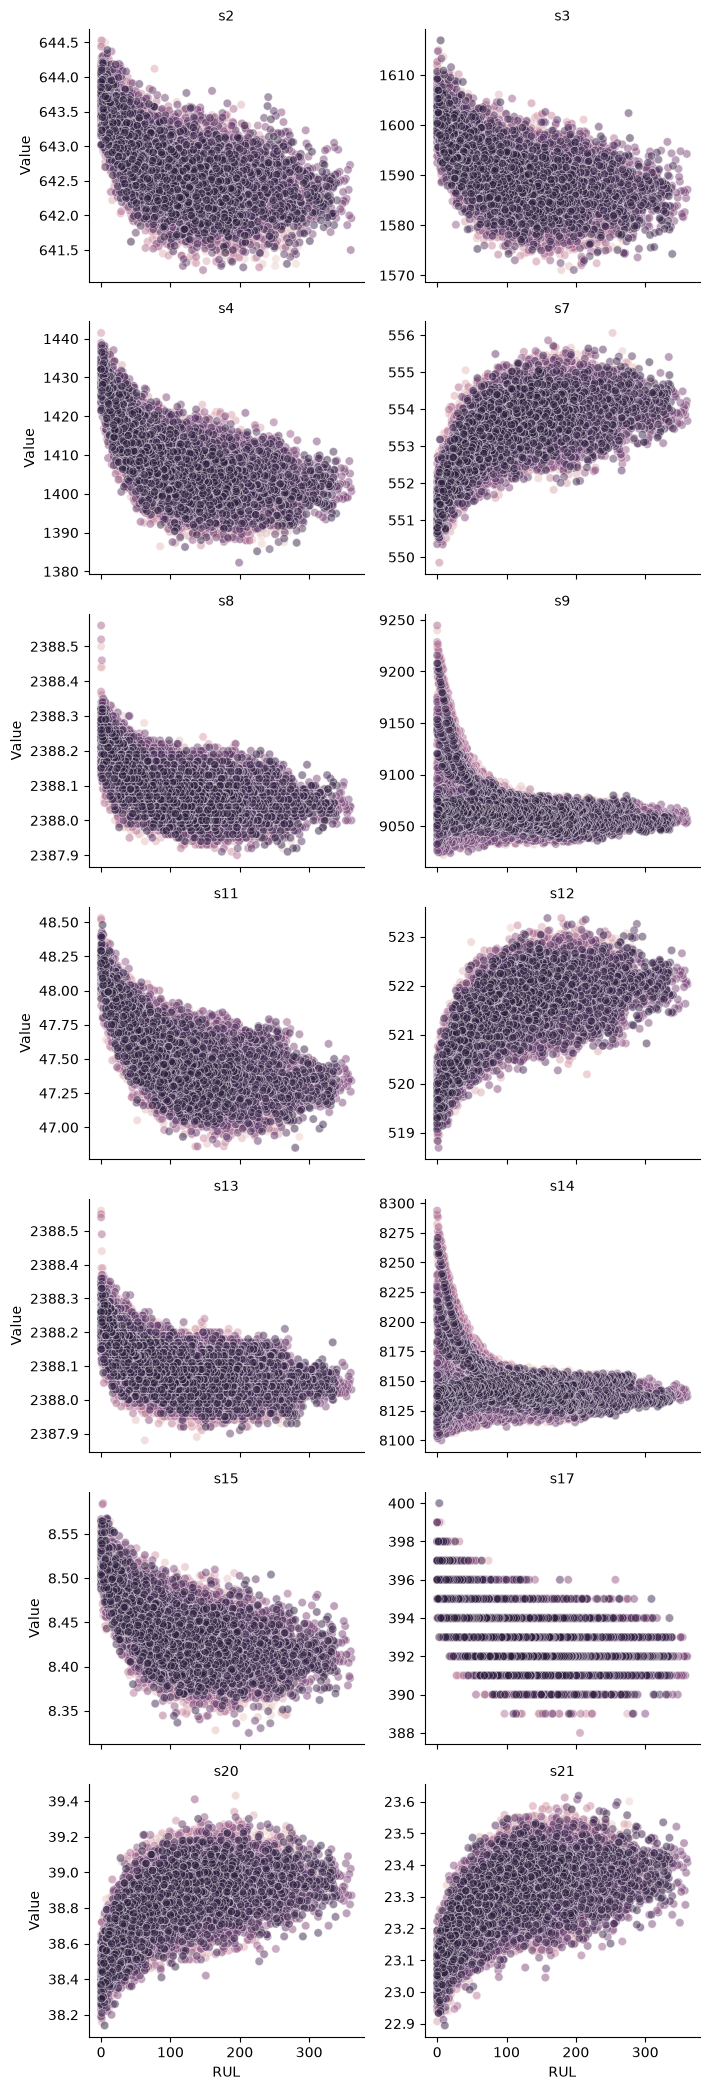

In [13]:
long_df = df.melt(
    id_vars=["RUL", "unit"],
    value_vars=high_variance_features,
    var_name="sensor",
    value_name="value"
)

g = sns.FacetGrid(
    long_df,
    col="sensor",
    col_wrap=2,
    height=3,
    aspect=1.2,
    sharey=False 
)

g.map_dataframe(
    sns.scatterplot,
    x="RUL",
    y="value",
    hue="unit",
    alpha=0.5,
    legend=False
)

g.set_axis_labels("RUL", "Value")
g.set_titles("{col_name}")

plt.show()

#### b) Low Variance Sensor Trends (Candidate for Removal)

Conversely, plotting the low-variance features shows flat, static lines across all cycles. Because these sensors offer no patterns regarding engine degradation, they will be removed from analysis.

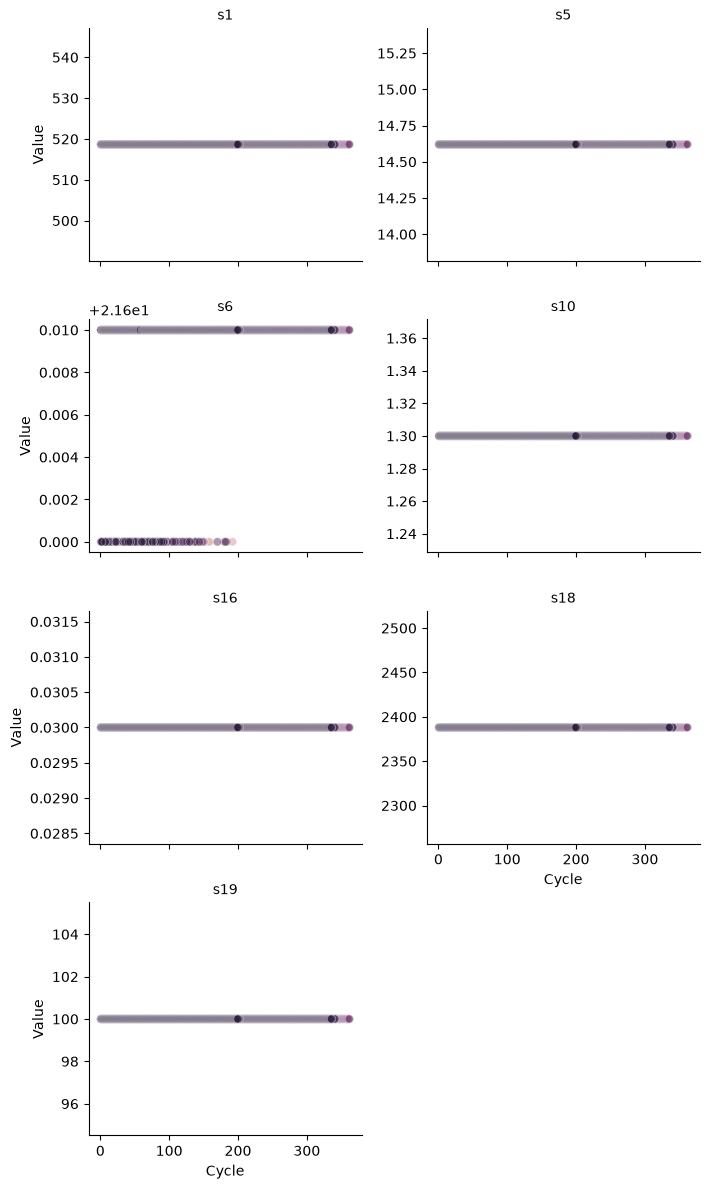

In [ ]:
long_df = df.melt(
    id_vars=["RUL", "unit"],
    value_vars=low_variance_features,
    var_name="sensor",
    value_name="value"
)

g = sns.FacetGrid(
    long_df,
    col="sensor",
    col_wrap=2,
    height=3,
    aspect=1.2,
    sharey=False 
)

g.map_dataframe(
    sns.scatterplot,
    x="RUL",
    y="value",
    hue="unit",
    alpha=0.5,
    legend=False
)

g.set_axis_labels("RUL", "Value")
g.set_titles("{col_name}")

plt.show()

### 5 - Target Variable Analysis & Multicollinearity

#### a) Distribution of Maximum RUL per Engine

To understand the distribution of engine lifespans within the dataset, we calculate the maximum cycle reached by each engine unit. The resulting histogram displays a balanced, roughly Gaussian distribution.

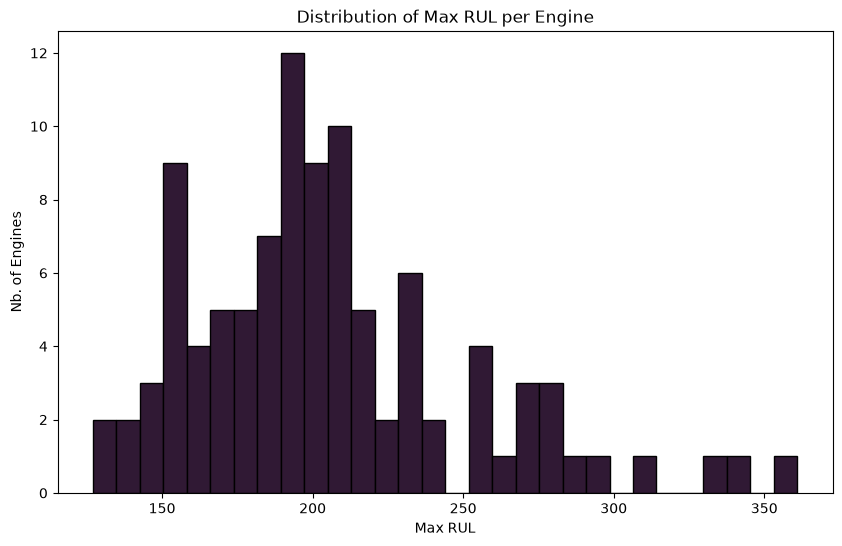

In [6]:
# Add the variable max_rul_per_engine to store the maximum RUL for each unit
max_rul = df.groupby("unit")["RUL"].max()

# Plot the distribution of max RUL per engine
plt.figure(figsize=(10, 6))
plt.hist(max_rul, bins=30, edgecolor='black', color='#301934')
plt.xlabel('Max RUL')
plt.ylabel('Nb. of Engines')
plt.title('Distribution of Max RUL per Engine')
plt.show()

#### b) Sensor Correlation Heatmap

Finally, we compute a Pearson correlation matrix for the high-variance sensors to identify redundant relationships. The heatmap reveals significant clusters of highly correlated variables.

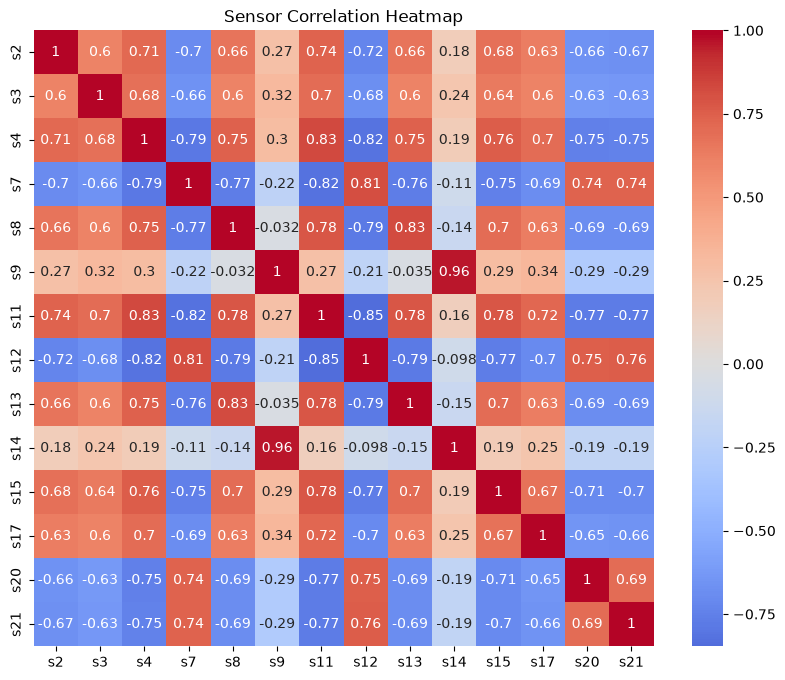

In [7]:
# Heatmap of sensor correlations to detect redundancy.
corr_matrix = df[high_variance_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Sensor Correlation Heatmap")
plt.show()